# EconML Example: Analyzing the Effects of Education Programs on Student Performance

**Goal.** Use the [UCI Student Performance dataset](https://archive.ics.uci.edu/dataset/320/student+performance) to estimate the **causal effect** of a school-based educational support program on students' final grades, and to explore **which student groups benefit the most**.

**Tools.**

- **EconML**: Causal inference with machine learning (treatment effect estimation).
- **ucimlrepo**: Programmatic access to the UCI ML Repository dataset.
- **Our wrapper (`econml_utils.py`)**: Utility layer to standardize how we load data and build EconML models.

This notebook is designed to be **self-contained** so a reader with no prior context could understand the dataset, the causal question, and how EconML is used here.

## 1. Notebook Summary

In this example we will:

1. **Load** the Student Performance dataset directly from the UCI ML Repository using `ucimlrepo`.
2. **Clean** and lightly encode the raw data (e.g., convert `yes`/`no` to `0`/`1`).
3. **Define the causal setup**:
   - Outcome (final grade `G3`)
   - Treatment (school support program `schoolsup`)
   - Features (X) and controls (W)
4. **Explore the data**:
   - Basic distributions of grades and key demographics
   - Differences between treated vs. control students
5. **Fit EconML models** to estimate:
   - Average Treatment Effect (ATE)
   - Heterogeneous effects (CATEs) across demographic groups.


## 2. Load the Student Performance dataset (UCI ML Repository)

We use the `ucimlrepo` Python package to download the **Student Performance** dataset
(ID = 320) directly from the UCI Machine Learning Repository.

The helper function `load_student_data()` in `econml_utils.py` wraps this logic:

- By default it calls `fetch_ucirepo(id=320)` and concatenates the features (`X`)
  and targets (`y`) into a single `pandas.DataFrame`.
- As a fallback, it can also load from a local CSV file if needed.

In [1]:
# If ucimlrepo is not already installed in the Docker image, install it.
# You can comment this out once the environment is set up.
!pip install -q ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

from econml_utils import (
    load_student_data,
    clean_student_data,
    make_default_config,
    split_y_t_x_w,
    summarize_treatment,
    build_econml_estimator,
    fit_econml_estimator,
    estimate_ate,
    estimate_cate_by_subgroup
)

In [2]:
# Load the raw dataset from UCI.
df_raw = load_student_data(source="ucimlrepo")

print(f"Raw dataset shape: {df_raw.shape}")
df_raw.head()

df_raw.info()
df_raw.describe(include="all").transpose().head(15)

Raw dataset shape: (649, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-n

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,649,2,GP,423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,649,2,F,383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,649.0,NaN,NaN,NaN,16.744222,1.218138,15.0,16.0,17.0,18.0,22.0
address,649,2,U,452,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,649,2,GT3,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,649,2,T,569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,649.0,NaN,NaN,NaN,2.514638,1.134552,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,NaN,NaN,NaN,2.306626,1.099931,0.0,1.0,2.0,3.0,4.0
Mjob,649,5,other,258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,649,5,other,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Cleaning and defining Y, T, X, W

The original dataset includes:

- Demographic and family information (e.g., `sex`, `age`, `Medu`, `Fedu`)
- Study behavior and school-related variables (e.g., `studytime`, `absences`)
- Several support flags:
  - `schoolsup`: extra educational school support (yes/no)
  - `famsup`: family educational support (yes/no)
  - `paid`: extra paid classes (yes/no)
- Three grade columns:
  - `G1`, `G2`: first and second period grades
  - `G3`: final grade

For this project we adopt the following **causal framing**:

- **Outcome (Y)**: `G3` - the final course grade.
- **Treatment (T)**: `schoolsup` - interpreted as participation in a school support program.
- **Features (X)** (treatment-effect heterogeneity):
  - `sex`, `age`, `Medu`, `Fedu`, `studytime`, `failures`, `higher`, `internet`, `absences`
- **Controls (W)** (confounding adjustment):
  - `G1`, `G2`, `famsup`, `paid`

The function `clean_student_data()`:

- Converts `yes`/`no` flags to 0/1
- Encodes a few categorical variables as 0/1 (e.g., `sex`, `school`, `address`, `Pstatus`)

The helper `make_default_config()` stores these column choices in an
`EconMLEducationConfig` object that we will pass to EconML later.

In [3]:
# Clean the raw data (e.g., map yes/no to 0/1, encode a few key categories).
df = clean_student_data(df_raw)

# Build the default causal configuration (Y, T, X, W).
config = make_default_config()
config

EconMLEducationConfig(outcome_col='G3', treatment_col='schoolsup', x_cols=['sex', 'age', 'Medu', 'Fedu', 'studytime', 'failures', 'higher', 'internet', 'absences'], w_cols=['G1', 'G2', 'famsup', 'paid'], estimator_type='linear_dml')

In [4]:
# How many treated vs control students, and what are their average final grades?
treatment_summary = summarize_treatment(df, config)
treatment_summary

,treatment,count,mean_outcome,std_outcome
0,0,581,11.979346,3.316040
1,1,68,11.279412,2.304088


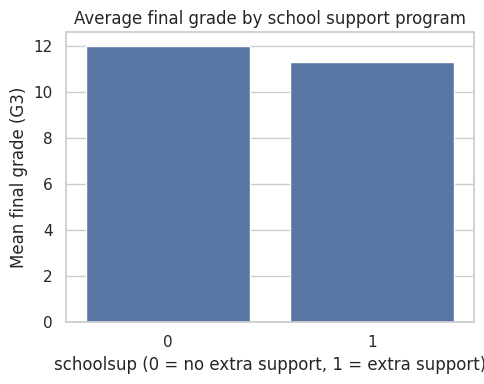

In [5]:
plt.figure(figsize=(5, 4))
sns.barplot(
    data=treatment_summary,
    x="treatment",
    y="mean_outcome",
)
plt.xlabel("schoolsup (0 = no extra support, 1 = extra support)")
plt.ylabel("Mean final grade (G3)")
plt.title("Average final grade by school support program")
plt.tight_layout()
plt.show()

## 4. Exploratory data analysis (EDA)

Before fitting causal models, we briefly explore the outcome and treatment:

- Distribution of final grades `G3`  
- How `G3` differs between treated and control students (`schoolsup`)  
- Basic covariate balance (do treated students look different from controls?)

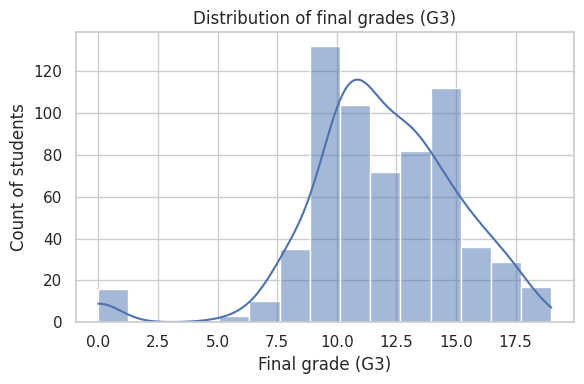

In [6]:
# Histogram of G3
plt.figure(figsize=(6, 4))
sns.histplot(df["G3"], bins=15, kde=True)
plt.xlabel("Final grade (G3)")
plt.ylabel("Count of students")
plt.title("Distribution of final grades (G3)")
plt.tight_layout()
plt.show()

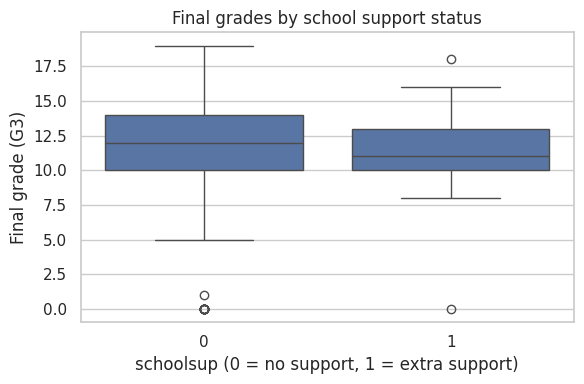

In [7]:
# Boxplot of G3 by schoolsup
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=df,
    x=config.treatment_col,
    y=config.outcome_col,
)
plt.xlabel("schoolsup (0 = no support, 1 = extra support)")
plt.ylabel("Final grade (G3)")
plt.title("Final grades by school support status")
plt.tight_layout()
plt.show()

In [8]:
# Covariate balance table
balance_cols = [
    "G1", "G2", "Medu", "Fedu", "studytime",
    "failures", "higher", "internet", "absences",
]

balance_table = (
    df.groupby(config.treatment_col)[balance_cols]
      .mean()
      .T  # transpose: rows = covariates, columns = treatment=0/1
)

balance_table

schoolsup,0,1
G1,11.466437,10.823529
G2,11.626506,11.088235
Medu,2.523236,2.441176
Fedu,2.297762,2.382353
studytime,1.905336,2.147059
failures,0.222031,0.220588
higher,0.884682,0.970588
internet,0.771084,0.735294
absences,3.753873,2.852941


## 5. Fit DML estimators & estimate ATEs

In [9]:
# 5. Estimate average treatment effects (ATE) with different DML estimators

ate_results = {}
models = {}

for est_type in ["linear_dml", "causal_forest", "sparse_linear_dml"]:
    print(f"Fitting estimator: {est_type}")
    config.estimator_type = est_type
    model = fit_econml_estimator(df, config)
    models[est_type] = model

    ate_res = estimate_ate(model, df, config)
    ate_results[est_type] = ate_res

ate_df = pd.DataFrame(ate_results).T   # rows = estimators; columns = ate, ci, etc
ate_df

Fitting estimator: linear_dml
Fitting estimator: causal_forest
Fitting estimator: sparse_linear_dml


,ate,ate_ci_lower,ate_ci_upper
linear_dml,0.015329,-0.364469,0.395127
causal_forest,0.040746,-1.011361,1.092853
sparse_linear_dml,-2.650475,-5.217776,-0.083174


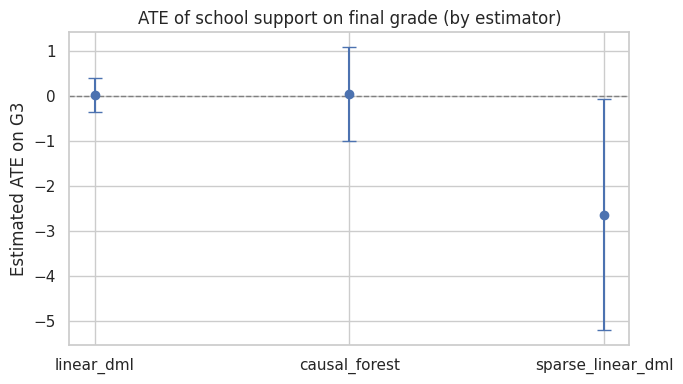

,ate,ate_ci_lower,ate_ci_upper,estimator
0,0.015329,-0.364469,0.395127,linear_dml
1,0.040746,-1.011361,1.092853,causal_forest
2,-2.650475,-5.217776,-0.083174,sparse_linear_dml


In [10]:
# Make a bar plot of ATEs with 95% confidence intervals.

plot_df = ate_df.copy()
plot_df["estimator"] = plot_df.index
plot_df = plot_df.reset_index(drop=True)

plt.figure(figsize=(7, 4))
plt.errorbar(
    x=plot_df["estimator"],
    y=plot_df["ate"],
    yerr=[
        plot_df["ate"] - plot_df["ate_ci_lower"],
        plot_df["ate_ci_upper"] - plot_df["ate"],
    ],
    fmt="o",
    capsize=5,
)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.ylabel("Estimated ATE on G3")
plt.title("ATE of school support on final grade (by estimator)")
plt.tight_layout()
plt.show()

plot_df

## 5. Heterogeneous Effects (CATE) By Subgroup

In [11]:
# Heterogeneity by sex for each estimator
subgroup = "sex"  # 0 = female, 1 = male

cate_by_sex = {}

for est_type, model in models.items():
    cate_df = estimate_cate_by_subgroup(model, df, config, subgroup_col=subgroup)
    cate_df["estimator"] = est_type
    cate_by_sex[est_type] = cate_df

pd.concat(cate_by_sex.values(), ignore_index=True)

,subgroup,cate_mean,cate_std,n,estimator
0,0,-0.218905,0.678109,383,linear_dml
1,1,0.352591,0.727971,266,linear_dml
2,0,0.020157,0.400552,383,causal_forest
3,1,0.070391,0.446682,266,causal_forest
4,0,-2.882089,0.790449,383,sparse_linear_dml
5,1,-2.316985,0.872553,266,sparse_linear_dml


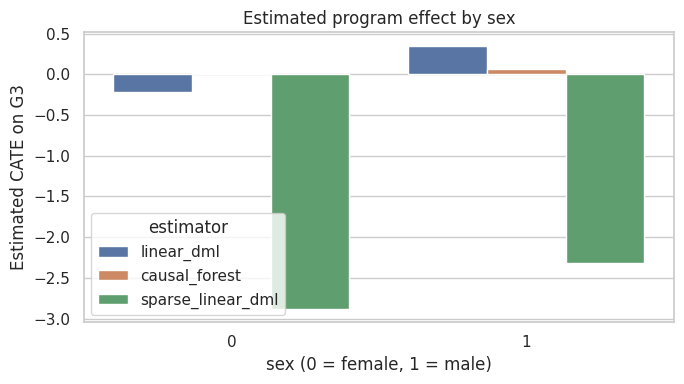

,subgroup,cate_mean,cate_std,n,estimator
0,0,-0.218905,0.678109,383,linear_dml
1,1,0.352591,0.727971,266,linear_dml
2,0,0.020157,0.400552,383,causal_forest
3,1,0.070391,0.446682,266,causal_forest
4,0,-2.882089,0.790449,383,sparse_linear_dml
5,1,-2.316985,0.872553,266,sparse_linear_dml


In [12]:
# Plot CATE by sex
combined_sex = pd.concat(cate_by_sex.values(), ignore_index=True)

plt.figure(figsize=(7, 4))
sns.barplot(
    data=combined_sex,
    x="subgroup",
    y="cate_mean",
    hue="estimator",
)
plt.xlabel("sex (0 = female, 1 = male)")
plt.ylabel("Estimated CATE on G3")
plt.title("Estimated program effect by sex")
plt.tight_layout()
plt.show()

combined_sex

In [13]:
# Heterogeneity by Medu (Mother's Education)
subgroup = "Medu"  # ordinal: 0–4
cate_by_medu = {}

for est_type, model in models.items():
    cate_df = estimate_cate_by_subgroup(model, df, config, subgroup_col=subgroup)
    cate_df["estimator"] = est_type
    cate_by_medu[est_type] = cate_df

combined_medu = pd.concat(cate_by_medu.values(), ignore_index=True)
combined_medu.sort_values(["estimator", "subgroup"], inplace=True)
combined_medu

,subgroup,cate_mean,cate_std,n,estimator
5,0,0.409051,0.449242,6,causal_forest
6,1,0.317105,0.367159,143,causal_forest
7,2,0.050394,0.384211,186,causal_forest
8,3,0.074134,0.372783,139,causal_forest
9,4,-0.234480,0.361642,175,causal_forest
0,0,0.910579,0.937419,6,linear_dml
1,1,0.567353,0.764553,143,linear_dml
2,2,0.086198,0.613736,186,linear_dml
3,3,-0.094700,0.729705,139,linear_dml
4,4,-0.454377,0.520747,175,linear_dml


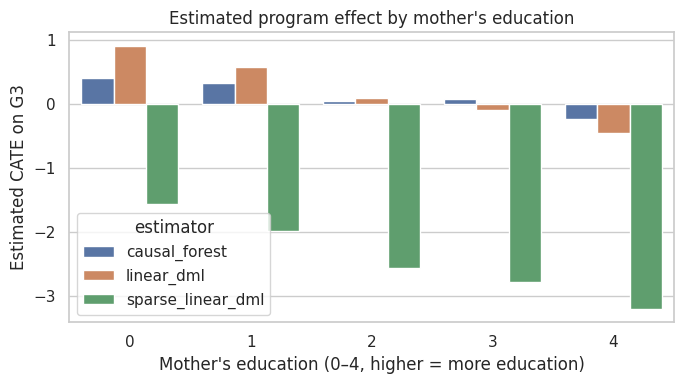

In [14]:
# Plot CATE by Medu
plt.figure(figsize=(7, 4))
sns.barplot(
    data=combined_medu,
    x="subgroup",
    y="cate_mean",
    hue="estimator",
)
plt.xlabel("Mother's education (0–4, higher = more education)")
plt.ylabel("Estimated CATE on G3")
plt.title("Estimated program effect by mother's education")
plt.tight_layout()
plt.show()

## 5. Robustness Check via Cross-Validated ATE

In [15]:
# Kfold ATE Stability for LinearDML
from sklearn.model_selection import KFold

def cross_validated_ate(df, config, n_splits=5, estimator_type="linear_dml"):
    ates = []
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_idx, test_idx in kf.split(df):
        train_df = df.iloc[train_idx]
        test_df = df.iloc[test_idx]

        config.estimator_type = estimator_type
        model = fit_econml_estimator(train_df, config)
        ate_res = estimate_ate(model, test_df, config)
        ates.append(ate_res["ate"])

    return np.array(ates)

# Run CV for LinearDML
config.estimator_type = "linear_dml"
cv_ates_linear = cross_validated_ate(df, config, n_splits=5, estimator_type="linear_dml")
cv_ates_linear, cv_ates_linear.mean(), cv_ates_linear.std()

(array([ 0.01316829, -0.13479629,  0.13495127,  0.11765364, -0.04727486]),
 0.01674041023850877,
 0.10122388458231321)

In [16]:
# Comparison for CausalForestDML
config.estimator_type = "causal_forest"
cv_ates_forest = cross_validated_ate(df, config, n_splits=5, estimator_type="causal_forest")
cv_ates_forest, cv_ates_forest.mean(), cv_ates_forest.std()

(array([-0.12155889, -0.11134172,  0.13736513, -0.10464622,  0.06396035]),
 -0.027244270320771702,
 0.10711977296845439)